In [1]:
import os
import warnings
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

from scipy.spatial.distance import cdist, pdist, squareform
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.sparse import csr_matrix
from sklearn.manifold import TSNE

from utils.Processing import plot_div_boxplots, diversity_statistics, annotate_values

# Specify settings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
os.environ["OMP_NUM_THREADS"] = "8"

# Plotting params
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["font.family"] = "Arial"

# 1. Discovery cohort TCR and microbiome overview

(Manuscript figures: Fig. 1A, 1B, 1C; Extended Data Fig. 1A, 1B)

In [2]:
# Base directory of the files
base_dir = Path("..").resolve()

# Directories containing the processed files
processed_dir = base_dir / "2_processed_data" / "0_discovery_data"

# Output directories for the figures and tables
figures_dir = base_dir / "3_figures" / "Figures"
figures_dir.mkdir(exist_ok=True)
tables_dir = base_dir / "3_figures" / "Tables"
tables_dir.mkdir(exist_ok=True)
suppl_dir = base_dir / "3_figures" / "Supplementary"
suppl_dir.mkdir(exist_ok=True)

### 1A. TCR richness & diversity

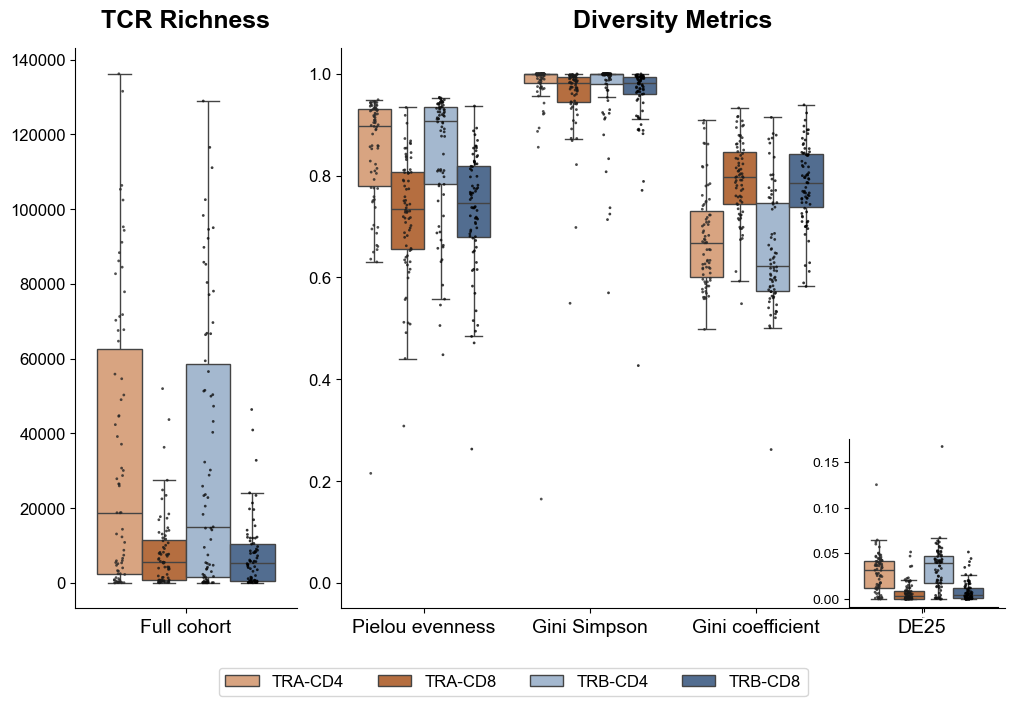

In [3]:
# Load and prepare data
div_df = pd.read_csv(processed_dir / "2_diversity_calc.csv")

# Define condition labels
div_df["Condition"] = (
    div_df["Chain"].astype(str) + "-" + div_df["Cell_type"].astype(str)
)

# Get the richness results separately
df_richness = div_df[["Patient", "Condition", "Richness"]].copy()
df_richness["x_value"] = "Full cohort"

# Diversity metrics
metrics_to_plot = ["Pielou_evenness", "Gini_Simpson", "Gini_coefficient", "DE25"]
df_long = div_df.melt(
    id_vars=["Patient", "Condition"],
    value_vars=metrics_to_plot,
    var_name="Metric",
    value_name="Value",
)
conditions = sorted(df_long["Condition"].unique())


#########################
### Figure generation ###
#########################

# Plotting settings
palette = {
    "TRA-CD4": "#e6a272",
    "TRB-CD4": "#9db7d6",
    "TRA-CD8": "#c96a2c",
    "TRB-CD8": "#476c9b",
}
add_annotations = False
annotation_test = "kruskal"

fig, axes = plt.subplots(
    1, 2, figsize=(12, 8), gridspec_kw={"width_ratios": [1, 3], "wspace": 0.1}
)

# Panel 1: Richness
plot_div_boxplots(
    axes[0],
    df_richness,
    x="x_value",
    y="Richness",
    hue="Condition",
    palette=palette,
    dodge=True,
    jitter=True,
    title="TCR Richness",
    xticklabels=["Full cohort"],
    show_legend=False,
)

if add_annotations:
    annotate_values(
        axes[0],
        df_richness.rename(columns={"Richness": "Value"}),
        conditions,
        value_col="Value",
        test=annotation_test,
    )

# Panel 2: Diversity metrics
plot_div_boxplots(
    axes[1],
    df_long,
    x="Metric",
    y="Value",
    hue="Condition",
    palette=palette,
    dodge=True,
    jitter=True,
    title="Diversity Metrics",
    xticklabels=[m.replace("_", " ") for m in metrics_to_plot],
    show_legend=False,
)

if add_annotations:
    for i, metric in enumerate(metrics_to_plot):
        df_metric = df_long[df_long["Metric"] == metric]
        annotate_values(
            axes[1],
            df_metric,
            value_col="Value",
            x_base=i,
            test=annotation_test,
        )

# Zoomed inset for DE25
axins = inset_axes(
    axes[1],
    width="45%",
    height="60%",
    bbox_to_anchor=(0.5, -0.185, 0.5, 0.5),
    bbox_transform=axes[1].transAxes,
)
plot_div_boxplots(
    axins,
    df_long[df_long["Metric"] == "DE25"],
    x="Metric",
    y="Value",
    hue="Condition",
    palette=palette,
    dodge=True,
    jitter=True,
    title="",
    xticklabels=None,
    show_legend=False,
)
axins.tick_params(axis="x", labelsize=0)
axins.tick_params(axis="y", labelsize=10)

if add_annotations:
    df_de25 = df_long[df_long["Metric"] == "DE25"]
    annotate_values(axins, df_de25, value_col="Value", test=annotation_test)


# Combined legend at bottom
handles, labels = axes[1].get_legend_handles_labels()
fig.legend(
    handles[: len(palette)],
    labels[: len(palette)],
    loc="lower center",
    ncol=4,
    fontsize=12,
    bbox_to_anchor=(0.49, 0.06),
)

plt.tight_layout()
plt.subplots_adjust(wspace=0.25, bottom=0.18)
plt.savefig(figures_dir / "1A_diversity.pdf", bbox_inches="tight")
plt.show()


################################
### Statistical significance ###
################################
results = []

# Richness
res_rich = diversity_statistics(
    df_richness.rename(columns={"Richness": "Value"}),
    metric_label="Richness",
    test=annotation_test,
    value_col="Value",
)
results.append(res_rich)

# Diversity metrics
for metric in metrics_to_plot:
    df_metric = df_long[df_long["Metric"] == metric]
    res_metric = diversity_statistics(
        df_metric,
        metric_label=metric,
        test=annotation_test,
        value_col="Value",
    )
    results.append(res_metric)

# Combine all stats and save
all_stats = pd.concat(results, ignore_index=True)
all_stats.to_csv(tables_dir / "diversity_stats.csv", index=False)

### 1C. Suppl. Beta diversity for the TCR repertoire

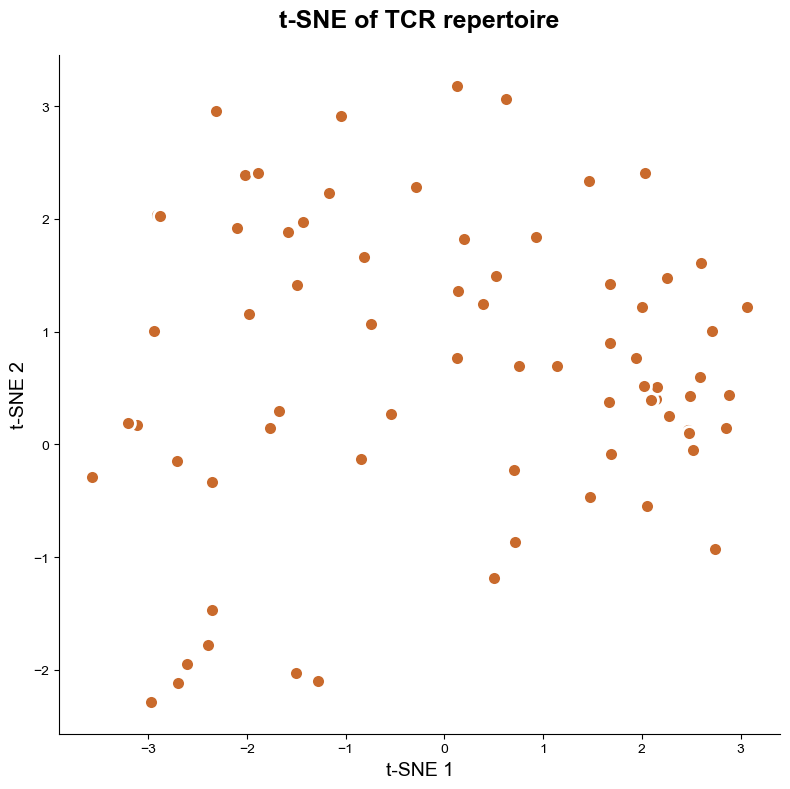

In [4]:
# Load processed TCR data
tcr_data = pd.read_csv(processed_dir / "0_final_data_parsed_annotated.csv")

# Make count table for all unique VDJ TCR values
count_df = tcr_data.pivot_table(
    index="patient", columns="full_tcr", aggfunc="size", fill_value=0
)

# Create a sparse matrix with relative abundance
X_sparse = csr_matrix(count_df.values, dtype=np.float32)
row_sums = np.array(X_sparse.sum(axis=1)).flatten()
row_indices, col_indices = X_sparse.nonzero()
X_sparse.data /= row_sums[row_indices]

# Calculate the pairwise distances using bray-curtis
X_dense = X_sparse.astype(np.float32).toarray()
dist_vector = pdist(X_dense, metric="braycurtis")
dist_matrix = squareform(dist_vector)

# t-SNE on precomputed distances
tsne = TSNE(
    n_components=2,
    metric="precomputed",
    random_state=42,
    init="random",
    learning_rate="auto",
)
tsne_result = tsne.fit_transform(dist_matrix)


#########################
### Figure generation ###
#########################
fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(
    tsne_result[:, 0],
    tsne_result[:, 1],
    c="#c96a2c",
    marker="o",
    edgecolors="white",
    s=100,
    linewidths=2,
    rasterized=True,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.set_title("t-SNE of TCR repertoire", size=18, pad=20, fontweight="bold")
ax.set_xlabel("t-SNE 1", size=14)
ax.set_ylabel("t-SNE 2", size=14)
ax.tick_params(axis="both", labelsize=10)

plt.tight_layout()
plt.savefig(suppl_dir / "S1_beta_diveristy_TCR.pdf", bbox_inches="tight")
plt.show()

### 1D. Suppl. Epitope predictions overview

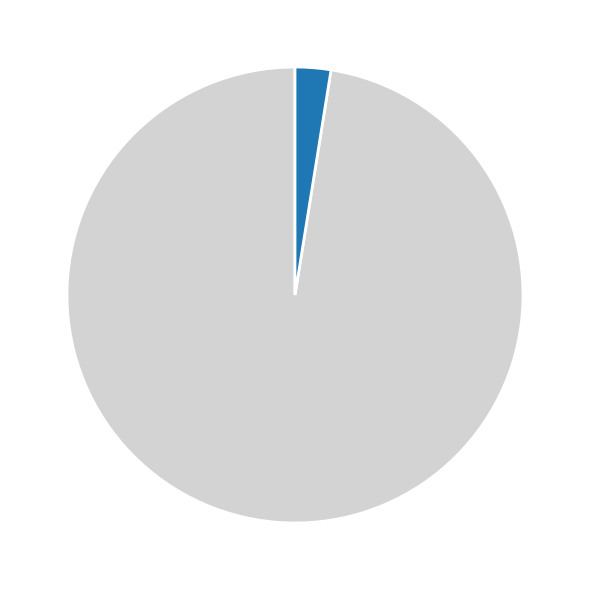

In [5]:
# Load the epitope annotations
tcr_data = pd.read_csv(processed_dir / "0_final_data_parsed_annotated.csv")
tcr_epitopes = tcr_data[tcr_data["Score"] >= 0.2]

tcr_epitopes_bact = tcr_epitopes[
    (tcr_epitopes["epitope_groups"] == "Microbial")
    & (tcr_epitopes["Epitope Species"] != "Triticum aestivum")
    & (tcr_epitopes["Epitope Species"] != "Plasmodium falciparum")
]

# Remove duplicate names
tcr_epitopes = tcr_epitopes.copy()
tcr_epitopes["Epitope Species"] = tcr_epitopes["Epitope Species"].replace(
    {"Synthetic": "Synthetic_"}
)

# Define labels
top_parents = tcr_epitopes["epitope_groups"].dropna().unique().tolist()
child_nodes = tcr_epitopes["Epitope Species"].dropna().unique().tolist()
labels = top_parents + child_nodes
parents = [""] * len(top_parents)

# Map species to group
species_to_group = (
    tcr_epitopes[["Epitope Species", "epitope_groups"]]
    .dropna()
    .drop_duplicates()
    .set_index("Epitope Species")["epitope_groups"]
    .to_dict()
)
parents.extend([species_to_group.get(sp, "") for sp in child_nodes])

# Values
dict_groups = tcr_epitopes["epitope_groups"].value_counts().to_dict()
dict_species = tcr_epitopes["Epitope Species"].value_counts().to_dict()
values = [dict_groups[p] for p in top_parents] + [
    dict_species[ch] for ch in child_nodes
]

# Colors
color_map = {
    "Viral": "#636EFA",
    "Human": "#EF553B",
    "Microbial": "#00CC96",
    "Synthetic": "#AB63FA",
}
colors = [
    color_map.get(lab, color_map.get(species_to_group.get(lab, ""), "lightgrey"))
    for lab in labels
]

############################################
### Figure generation: Sunburst epitopes ###
############################################

fig = go.Figure(
    go.Sunburst(
        labels=labels,
        parents=parents,
        values=values,
        branchvalues="total",
        marker=dict(colors=colors),
        insidetextorientation="radial",
    )
)
fig.update_layout(margin=dict(t=5, l=5, r=5, b=5))
fig.write_image(suppl_dir / "S1_sunburst_noepitopes.pdf")
fig.show()


####################################
### Figure generation: Pie chart ###
####################################

main_counts = [len(tcr_data) - len(tcr_epitopes), len(tcr_epitopes)]
main_colors = ["#D3D3D3", "#1F78B4"]

plt.figure(figsize=(6, 6))
plt.pie(
    main_counts,
    labels=["", ""],
    colors=main_colors,
    startangle=90,
    textprops={"fontsize": 20},
    wedgeprops={"linewidth": 2, "edgecolor": "white"},
)
plt.tight_layout()
plt.savefig(suppl_dir / "S1_small_pie.pdf", bbox_inches="tight")
plt.show()

# 2. Microbial abundance and t-SNE

Plot the microbial abundance of the top 9 genera across all individual samples and explore beta diveristy distribution across the space

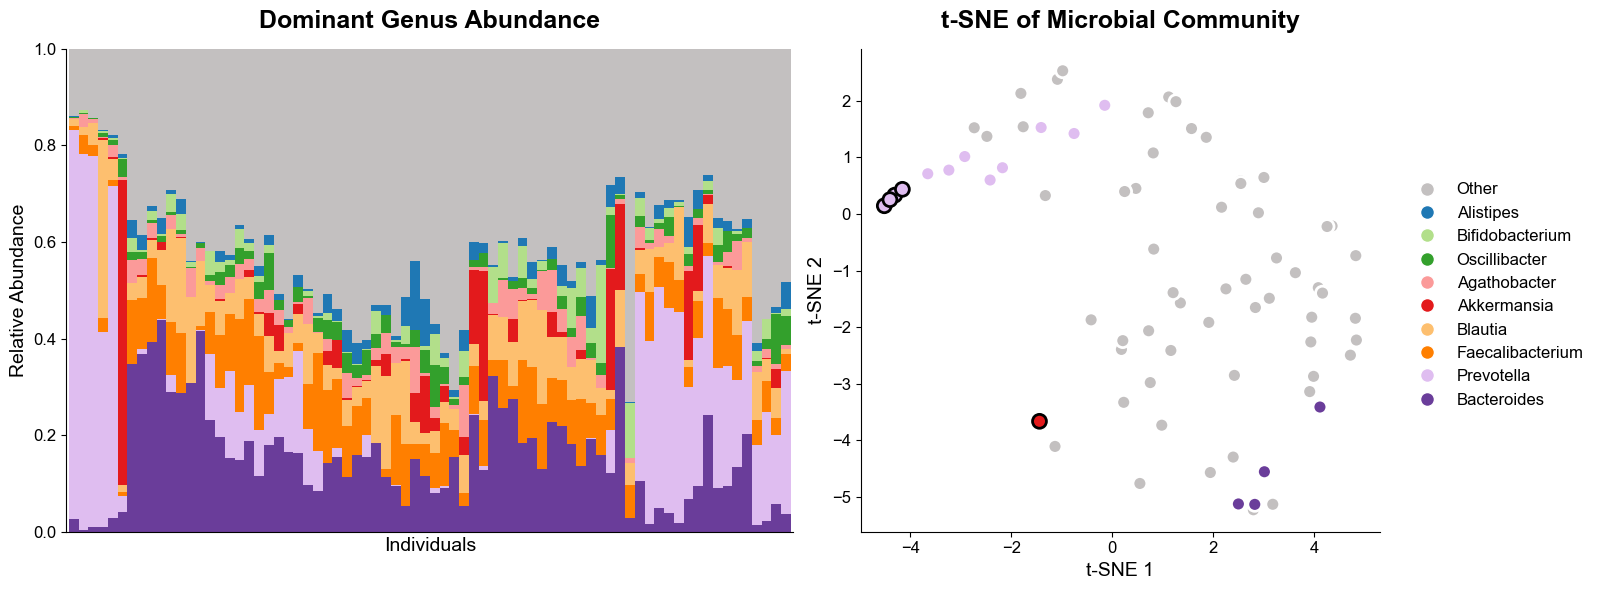

In [6]:
# Load microbial data
micro_taxa = pd.read_csv(
    base_dir / "1_raw_data" / "0_discovery_data" / "Microbiome_taxa.csv", index_col=0
)
micro_counts = pd.read_csv(
    base_dir / "1_raw_data" / "0_discovery_data" / "Microbiome_asv_counts.csv",
    index_col=0,
)

# Merge taxonomy with counts
micro_merged = pd.merge(
    micro_counts,
    micro_taxa[["genus", "taxon_id", "taxon_name"]],
    on="taxon_id",
    how="left",
)

# Relative abundance and top taxa selection
df_pivot = micro_merged.pivot_table(
    index="sample_id", columns="genus", values="count", aggfunc="sum", fill_value=0
)
df_rel_abundance = df_pivot.div(df_pivot.sum(axis=1), axis=0)

top_taxa = df_rel_abundance.sum(axis=0).nlargest(9).index
df_selected = df_rel_abundance.copy()
df_selected["Other"] = 1 - df_selected[top_taxa].sum(axis=1)
df_selected = df_selected[top_taxa.tolist() + ["Other"]]
taxon_order = top_taxa.tolist() + ["Other"]

# Color palette
custom_colors = [
    "#6A3D9A",
    "#DFBDF0",
    "#FF7F00",
    "#FDBF6F",
    "#E31A1C",
    "#FB9A99",
    "#33A02C",
    "#B2DF8A",
    "#1F78B4",
    "#C3C0C0",
]
color_palette = dict(zip(taxon_order, custom_colors))


# Hierarchical clustering for barplot order
distance_matrix_hc = cdist(df_selected.values, df_selected.values, metric="braycurtis")
Z = linkage(distance_matrix_hc, method="complete")
sample_order = fcluster(Z, t=0.1, criterion="distance")
df_sorted = df_selected.iloc[np.argsort(sample_order)]


# t-SNE on full microbial composition
distance_matrix_tsne = cdist(
    df_rel_abundance.values, df_rel_abundance.values, metric="braycurtis"
)
tsne_results = TSNE(n_components=2, random_state=42).fit_transform(distance_matrix_tsne)

# Color points by top genus and dominant mask
top_genus = df_selected.idxmax(axis=1)
dominant_mask = df_selected.drop(columns=["Other"]).max(axis=1) > 0.50
colors = top_genus.map(color_palette)


#########################
### Figure generation ###
#########################
fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(14, 6), gridspec_kw={"width_ratios": [1.4, 1]}
)

# Panel 1: Microbial abudance barplot
df_sorted.plot(
    kind="bar",
    stacked=True,
    color=[color_palette[t] for t in df_sorted.columns],
    width=1,
    ax=ax1,
    edgecolor="none",
    legend=False,
)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.set_xlabel("Individuals", fontsize=14)
ax1.set_ylabel("Relative Abundance", fontsize=14)
ax1.set_title("Dominant Genus Abundance", fontsize=18, fontweight="bold", pad=15)
ax1.set_xticks([])
ax1.tick_params(axis="y", labelsize=12)
ax1.set_ylim(0, 1)

# Panel 2: t-SNE of microbial community
ax2.scatter(
    tsne_results[:, 0],
    tsne_results[:, 1],
    c=colors,
    s=100,
    alpha=1,
    edgecolors=["black" if d else "white" for d in dominant_mask],
    linewidths=2,
    rasterized=True,
)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.set_title("t-SNE of Microbial Community", fontsize=18, fontweight="bold", pad=15)
ax2.set_xlabel("t-SNE 1", fontsize=14)
ax2.set_ylabel("t-SNE 2", fontsize=14)
ax2.tick_params(axis="both", labelsize=12)

# Shared legend
reversed_taxon_order = taxon_order[::-1]
handles = [
    Line2D(
        [0], [0], marker="o", color="w", markerfacecolor=color_palette[t], markersize=10
    )
    for t in reversed_taxon_order
]
fig.legend(
    handles=handles,
    labels=reversed_taxon_order,
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    frameon=False,
    fontsize=12,
)

plt.tight_layout()
plt.savefig(figures_dir / "1B_C_micro_abundance.pdf", bbox_inches="tight")
plt.show()